---
tags: [algorithm, finance, variational]
---

# パウリ相関符号化を用いた大規模ポートフォリオ最適化

ポートフォリオ最適化は、金融における意思決定の要です。
リスクとリターンのバランスを取るために、これまでは古典的な計算手法が用いられてきました。
そして近年では、量子コンピュータを用いた有望な代替手法が提案されています。
しかし現在の量子ハードウェアでは、量子ビット数やノイズの制限のために、その実装にも限界がありました。
そこで本記事では、現実のポートフォリオ最適化問題に変分量子アルゴリズムを適用することを目的とした研究 [Soloviev & Krompiec (2025)](https://arxiv.org/abs/2511.21305) について解説します。
またその Qamomile での実装例を示しました。

In [68]:
# Install the latest Qamomile through pip! 
# !pip install qamomile

In [92]:
import glob
import os
from collections import deque

import kagglehub
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.optimize import minimize

import qamomile.circuit as qmc
from qamomile.circuit.algorithm.basic import ry_layer, rz_layer
from qamomile.optimization.binary_model import BinaryModel, BinarySampleSet
from qamomile.optimization.pce import PCEConverter
from qamomile.qiskit import QiskitTranspiler

## 背景

### 問題: ポートフォリオ最適化

ポートフォリオ最適化問題は、期待リターンの最大化とリスクの最小化を両立することを目指したものです。
現実の制約と市場の次元が増加すると、古典計算では対処しきれなくなります。
そこで組合せ最適化の新しい手法として、量子計算手法が注目されています。
量子回路手法では、量子近似最適化アルゴリズム (QAOA) と変分量子固有値ソルバー (VQE) が多く研究されてきました。
しかしながら、必要な量子ビット数が資産数 $m$ に線形で増加するという欠点がありました。
大きな量子回路を小さな量子回路に分割する、回路切断 (circuit cutting) と呼ばれる手法も提案されています。
しかしそれでも扱える規模は $m < 100$ にとどまっています。
量子回路以外の手法として、量子アニーラを用いた大規模な組合せ最適化計算も提案されています。
これらは数百から数千の資産を扱えるものの、これらの手法が量子優位性を持つことは示されていません。

### 先行研究

先ほど説明した通り、QAOA や VQE では、多くの変数が扱えないボトルネックがありました。
[Soloviev et al. (2025)](https://arxiv.org/abs/2506.08947) では、回路切断によるポートフォリオ最適化を研究しました。
マーケットグラフを分割し、ポートフォリオを組む手法により、量子ビット数を削減する方法を示しました。
しかし、切断された回路から得られた解に行う後処理実行時間が増大するデメリットもあるため、[Soloviev et al. (2025)](https://arxiv.org/abs/2506.08947) でも提示されたのは、71 量子ビットまでの計算のみでした。
また、量子ポートフォリオ最適化に特化したベンチマークを行った研究に、[Stopfer & Wagner (2025)](https://arxiv.org/abs/2509.17876) があります。
このベンチマークでは、混合整数計画法を用いた手法や問題特化型のヒューリスティクスが、QAOA と量子アニーリングを一貫して凌駕することを示しました。
そこで、[Soloviev & Krompiec (2025)](https://arxiv.org/abs/2511.21305) では、[Sciorilli et al. (2025)](https://www.nature.com/articles/s41467-024-55346-z) で提案されたパウリ相関符号化 (PCE) を用いた 変分最適化手法 により、これらの限界を突破することを試みました。

### 定式化

ポートフォリオ最適化は [Markowitz (1952)](https://onlinelibrary.wiley.com/doi/10.1111/j.1540-6261.1952.tb01525.x) で定式化されました。
ポートフォリオの期待リターンを、各銘柄の重み付き和として表現します。

$$
\mu_p 
= \sum_{i=1}^N w_i \mu_i \tag{1}
$$

ここで $w_i, \mu_i$ はそれぞれ、$i$ 番目の銘柄の重みと期待リターンです。
この期待リターンを最大化することが、ポートフォリオ最適化の目的関数となります。  
ポートフォリオ最適化において、リスクはポートフォリオの分散として定式化されます。
この分散は、次式のように定式化することができます。

$$
\sigma_p^2 
= \sum_{i=1}^N \sum_{j=1}^N w_i w_j \mathrm{Cov} (r_i, r_j) \tag{2}
$$

ここで $\mathrm{Cov} (r_i, r_j)$ は、$i$ 番目の銘柄のリターン $r_i$ と $j$ 番目の銘柄のリターン $r_j$ の共分散です。
これが負の値になるように最小化することで、例えばある銘柄で損失が発生していても、別の銘柄で利益が生まれるようになります。
これにより、全体としてリスクを最小化できることになります。  
これらを用いた平均・分散の枠組みに加え、ポートフォリオの運用を評価する指標として、シャープレシオがあります ([Sharpe (1966)](https://www.jstor.org/stable/2351741))。
これはリスクなしで得られるリターンを上回った超過収益を、ポートフォリオのリターンの標準偏差と比較することにより、ポートフォリオのリスク調整後のリターンを測ったものです。
具体的には、次のように書かれます。

$$
\mathrm{Sharpe \ Ratio} 
= \frac{\mu_p - r_f}{\sigma_p} \tag{3}
$$

ここで $r_f$ は、リスクなしで得られるリターンを表します。
この値が大きいほど、リスクを取ったことで得られる超過リターンが大きいことを表します。
この値が小さい場合、リスクを冒しても得られる超過リターンが少ないため、有効なポートフォリオではないことがわかります。

### パウリ相関符号化 (PCE)

PCE は [Sciorilli et al. (2025)](https://www.nature.com/articles/s41467-024-55346-z) により提案された、量子ビット効率の良い符号化手法です。
$m$ 個のバイナリ変数 $x_1, x_2, \dots, x_m \in \{-1, 1\}$ を考え、この変数を用いた目的関数 $f(\boldsymbol{x})$ を最小化したいとしましょう。
QAOA などの変分量子アルゴリズムでは 1 変数を表現するのに 1 量子ビットを用いるため、大規模な問題を表現するには多数の量子ビットが必要となります。
これに対し PCE は、より少ない量子ビットで、問題を効率よく表現するのに用いられます。  
$n$ 量子ビットに対し、$k$ 個にだけパウリ演算子 $X, Y, Z$ が作用する演算子を、$k$ 体のパウリ相関関数 (k-body Pauli correlators) と呼びます。
例えば、$n=3, k=2$ の場合

$$
\Pi_1^{(2)}
= Z_1 \otimes Z_2 \otimes I_3, \quad \Pi_2^{(2)} 
= X_1 \otimes I_2 \otimes Y_3 \dots \tag{1}
$$

などが考えられます。
$m$ 個のパウリ文字列 $\Pi^{(k)} = \{\Pi_1^{(k)}, \Pi_2^{(k)}, \dots, \Pi_m^{(k)}\}$ を考え、$n$ 量子ビットのパラメトライズ量子状態 $\vert \Psi (\boldsymbol{\theta}) \rangle$ に対する $\Pi_i^{(k)}$ の期待値を計算しましょう。
すると

$$
c_i 
= \langle \Psi (\boldsymbol{\theta}) \vert \Pi_i^{(k)} \vert \Psi (\boldsymbol{\theta}) \rangle \tag{2}
$$

のようになります。
この $c_i$ の符号、すなわち $\mathrm{sgn} (c_i)$ を考えることで、$i$ 番目のバイナリ変数 $x_i$ を表現するのがパウリ相関符号化です。
先ほどの $k=2$ の例の場合、$n$ 量子ビットのうちの 2 つにのみ $X, Y, Z$ のいずれかを作用させる場合の数は ${}_n C_2 \times 3^2 = \frac{3^2}{2} n (n-1)$ です。
このため、$m = \mathcal{O} (n^2)$ のバイナリ変数を表現可能であることがわかります。
同様に $k=3$ では ${}_n C_3 \times 3^3 = \frac{3^2}{2} n (n-1) (n-2)$ であることから、$m = \mathcal{O} (n^3)$ のバイナリ変数を表現することができます。
バイナリ変数 $x_i$ を連続緩和した $c_i$ を考えることで、その表現能力を向上させたものと見ることもできます。
また [Sciorilli et al. (2025)](https://www.nature.com/articles/s41467-024-55346-z) では、変分量子アルゴリズムでしばしば問題となる不毛のプラトーが、超多項式で抑制されることも示しました。

## 提案手法

ここまでの議論を踏まえて、[Soloviev & Krompiec (2025)](https://arxiv.org/abs/2511.21305) で提案された手法を詳しく見ていきましょう。

### マーケットグラフ表現とグラフ分割

先ほどは、平均・分散を用いた標準的なポートフォリオ最適化について説明しました。
しかしここでは、この標準的な手法を解くのではなく、次のような工夫を行なっています。
まずは銘柄の情報を、重み付きのグラフで表現します。
銘柄をノードとし、辺の有無と重みは

$$
w_{ij} 
= \left\{ \begin{array}{ll}
1 - \vert \rho_{ij} \vert & \mathrm{if} \ \vert \rho_{ij} \vert > \lambda \\
\emptyset & \mathrm{otherwise}
\end{array} \right. \tag{3}
$$

のように計算されます。
ここで 

$$
\rho_{ij} 
= \frac{\mathrm{Cov} (r_i, r_j)}{\sigma_i \sigma_j} \tag{4}
$$

は銘柄 $i, j$ の相関を表す係数であり、$\sigma_i$ は銘柄 $i$ の標準偏差です。
式 (4) は $\rho_{ij}$ の大きさが大きい、すなわち、強い相関がある頂点ペアほど重みが小さくなるように設計されています。
これにより、このグラフの MaxCut を考えた場合、結果として相関が弱い辺を切断することになります。
このようにして得られた各クラスタには、相関の強いものどうしの銘柄が残ります。
直接、式 (4) を辺の重みにし、MinCut をすることも可能ですが、その場合、先ほどの PCE を直接適用することができません。  
式 (3) の重みを持つ辺から構成されるグラフを、再帰的に分割することで、相関が強いものどうしによるクラスタリングを行うことができます。
分割を行うための関数は、次のように表現されます。

$$
\mathrm{Cut} (\mathcal{G}, \boldsymbol{x}) 
= \sum_{(v_i, v_j) \in E} w_{ij} x_i (1-x_j) \tag{5}
$$

ここで、$x_i \in \{ 0, 1 \}$ はどちらのクラスタに属するかを表すバイナリ変数です。
式 (5) は、$ (x_i, x_j) = (0, 1), (1, 0)$ のときにゼロとなります。
この分割を再帰的に行うことで、クラスタリングを完了します。  
このようにしてできた各クラスタ $L_i$ について、リターンベクトル $\boldsymbol{\mu}_i = [\mu_i^1, \mu_i^2, \dots, \mu_i^{\vert L_i \vert}]$ を計算し

$$
r_i 
= \mathrm{arg} \max_j \mu_i^j \tag{6}
$$

から、最大リターン銘柄を選出します。
よって、最終的に得られるポートフォリオは $\boldsymbol{r} = \{r_1, r_2, \dots, r_{n_\mathrm{sp} + 1}\}$ となります。
ここで $n_\mathrm{sp}$ は、グラフ分割の実施回数です。

### 損失関数

分割のための損失関数は、式 (5) で与えられます。
しかしこの式の形では微分ができず、勾配降下法などの最適化手法が適用できません。
そこでここでは 、[Sciorilli et al. (2025)](https://www.nature.com/articles/s41467-024-55346-z) で提案された損失関数を用いることにしましょう。

$$
\mathcal{L} 
= \sum_{(i, j) \in E} w_{ij} \tanh (\alpha \langle \Pi_i \rangle) \tanh (\alpha \langle \Pi_j \rangle) + \mathcal{L}^\mathrm{reg} \tag{7}
$$

ここで $E$ は分割前のグラフの辺集合であり、$\langle \Pi_i \rangle = \langle \Psi (\boldsymbol{\theta}) \vert \Pi_i^{(k)} \vert \Psi (\boldsymbol{\theta}) \rangle$ です。
$\alpha$ は $\tanh$ の鋭さを制御するパラメータで、論文では $\alpha = n^{\lfloor k/2 \rfloor}$ が最適な値として用いられています。
そして $\mathcal{L}^\mathrm{reg}$ は、正則化項を表します。  
通常の VQE や QAOA では、単一のハミルトニアン期待値を用います。
しかし、ここで提案されている手法では $\mathcal{L}$ は $m$ 個の パウリ文字列の期待値の非線形関数となります。

## Qamomile での実装

これまでの議論を踏まえて、[Soloviev & Krompiec (2025)](https://arxiv.org/abs/2511.21305) で示された方法を Qamomile で実装してみましょう。

### データの準備

ここでは、Kaggle の S&P 500 データセットから、必要となる平均リターン・分散を用意しましょう。
期間中に新規に上場した銘柄は履歴が短いために、欠損値が存在します。
欠損値を持たない、全期間で数値が存在するデータのみを抽出しましょう。

In [93]:
path = kagglehub.dataset_download("camnugent/sandp500")
print("dataset path:", path)

# 展開先のディレクトリ構造はバージョンで変わることがあるので glob で探す
csv_candidates = glob.glob(os.path.join(path, "**", "all_stocks_5yr.csv"), recursive=True)
print("found:", csv_candidates)
CSV = csv_candidates[0]

raw = pd.read_csv(CSV)
raw.columns = [c.lower() for c in raw.columns]   # date/Date の揺れを吸収
raw["date"] = pd.to_datetime(raw["date"])

print(raw.shape)
print(f"tickers: {raw['name'].nunique()}")
print(f"period : {raw['date'].min().date()} - {raw['date'].max().date()}")

# 縦持ち -> 横持ち (日付 x 銘柄)
wide = raw.pivot(index="date", columns="name", values="close").sort_index()

# 欠損処理: 全期間そろっている銘柄だけ残す
n_days = len(wide)
complete = wide.columns[wide.notna().sum() == n_days]
print(f"complete history : {len(complete)} / {wide.shape[1]}")
wide = wide[complete]

dataset path: /home/jovyan/.cache/kagglehub/datasets/camnugent/sandp500/versions/4
found: ['/home/jovyan/.cache/kagglehub/datasets/camnugent/sandp500/versions/4/all_stocks_5yr.csv']
(619040, 7)
tickers: 505
period : 2013-02-08 - 2018-02-07
complete history : 470 / 505


次に、最適化に用いる銘柄を抽出します。
ここでは、アルファベット順に先頭から `M` 個の銘柄を選択することにしましょう。
そして銘柄のリターンの時系列データを、学習データとテストデータに分割します。

In [94]:
M = 30    # 銘柄数 (論文は 10, 20, 30, 50, 100, 150, 200, 250)

# 銘柄選択規則: アルファベット順先頭 M 件。
# 代替案: 出来高上位 M 件、セクター均等抽出、ランダム抽出 (シード固定) など
tickers = sorted(wide.columns)[:M]
prices = wide[tickers]

returns = prices.pct_change().dropna()

# 時系列で 80:20 に分割 (論文と同じ)
split = int(len(returns) * 0.8)
train, test = returns.iloc[:split], returns.iloc[split:]

print(f"tickers: {tickers}")
print(f"\ntrain: {train.shape}  ({train.index[0].date()} - {train.index[-1].date()})")
print(f"test : {test.shape}  ({test.index[0].date()} - {test.index[-1].date()})")

# 分割・配当未調整データの影響チェック: 日次リターンの極端値
print(f"\n最大の日次変動 (分割の可能性):")
print(returns.abs().max().sort_values(ascending=False).head(5).round(3))

tickers: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AGN', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'ALL', 'ALXN']

train: (1006, 30)  (2013-02-11 - 2017-02-07)
test : (252, 30)  (2017-02-08 - 2018-02-07)

最大の日次変動 (分割の可能性):
name
ALGN    0.262
A       0.261
AKAM    0.212
ALXN    0.211
AAP     0.203
dtype: float64


### マーケットグラフの構築

式 (3) に従って、マーケットグラフを作成しましょう。
ただし、論文では $\lambda$ が指定されていないため、論文で用いられているグラフ密度を再現するような $\lambda$ を探索することから始めます。

In [95]:
# lambda の較正: 論文 Table 1 の密度 0.53-0.87 に入る値を探す。
# 実データの株式相関はほぼ正で 0.2-0.6 に集中する。M を変えたら必ず振り直す。
rho = train.corr().to_numpy()
iu = np.triu_indices(M, k=1)

print(f"|rho| 分布: min={np.abs(rho[iu]).min():.3f} "
      f"median={np.median(np.abs(rho[iu])):.3f} max={np.abs(rho[iu]).max():.3f}\n")

for lam in np.arange(0.10, 0.65, 0.05):
    A = (np.abs(rho) > lam) & ~np.eye(M, dtype=bool)
    g = nx.from_numpy_array(A)
    g.remove_edges_from(nx.selfloop_edges(g))
    mark = "  <-- 論文の範囲" if 0.53 <= nx.density(g) <= 0.87 else ""
    print(f"lambda={lam:.2f}  edges={g.number_of_edges():5d}  "
          f"density={nx.density(g):.3f}  clustering={nx.average_clustering(g):.3f}{mark}")

|rho| 分布: min=0.112 median=0.313 max=0.780

lambda=0.10  edges=  435  density=1.000  clustering=1.000
lambda=0.15  edges=  425  density=0.977  clustering=0.980
lambda=0.20  edges=  388  density=0.892  clustering=0.938
lambda=0.25  edges=  333  density=0.766  clustering=0.868  <-- 論文の範囲
lambda=0.30  edges=  252  density=0.579  clustering=0.823  <-- 論文の範囲
lambda=0.35  edges=  142  density=0.326  clustering=0.697
lambda=0.40  edges=   71  density=0.163  clustering=0.431
lambda=0.45  edges=   32  density=0.074  clustering=0.284
lambda=0.50  edges=   14  density=0.032  clustering=0.104
lambda=0.55  edges=    8  density=0.018  clustering=0.056
lambda=0.60  edges=    3  density=0.007  clustering=0.000


先ほどの結果から $\lambda$ を決定し、実際にグラフを構築しましょう。
ここでは、構築されたグラフの情報を表示しています。

nodes          : 30
edges          : 252
density        : 0.579   (論文 0.53-0.87)
avg degree     : 16.8
avg clustering : 0.823   (論文 0.70-0.95)
isolated       : 0  []


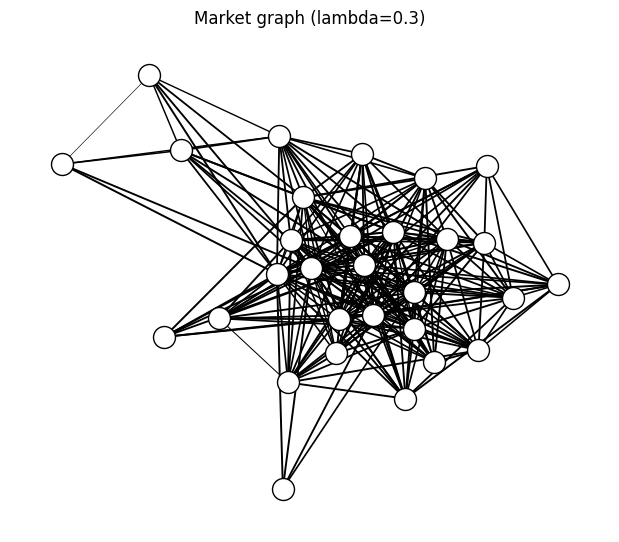

In [96]:
LAMBDA = 0.3    # 上のスイープ結果を見て決める

rho = train.corr().to_numpy()   # スイープセルを飛ばしても動くよう再計算

G = nx.Graph()
G.add_nodes_from(range(M))
nx.set_node_attributes(G, {i: t for i, t in enumerate(tickers)}, "ticker")
for i in range(M):
    for j in range(i + 1, M):
        if abs(rho[i, j]) > LAMBDA:
            G.add_edge(i, j, weight=1.0 - abs(rho[i, j]))

print(f"nodes          : {G.number_of_nodes()}")
print(f"edges          : {G.number_of_edges()}")
print(f"density        : {nx.density(G):.3f}   (論文 0.53-0.87)")
print(f"avg degree     : {2 * G.number_of_edges() / M:.1f}")
print(f"avg clustering : {nx.average_clustering(G):.3f}   (論文 0.70-0.95)")

# 孤立ノード = どの銘柄とも |rho| > lambda を満たさない銘柄。
# カットに寄与しないので符号化の対象から外す (3 節の bipartition 参照)。
iso = [v for v in G.nodes() if G.degree(v) == 0]
print(f"isolated       : {len(iso)}  {[tickers[v] for v in iso]}")

pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(6, 5))
nx.draw(G, pos, node_size=250, node_color="white", edgecolors="black",
        width=[2 * d["weight"] for _, _, d in G.edges(data=True)])
plt.title(f"Market graph (lambda={LAMBDA})")
plt.show()

### ハイパーパラメータの設定

ここで、種々のパラメータを設定しましょう。
`K` は相関演算子の次数、`BETA` は正則化項の大きさを表す定数、`MAXITER` は古典最適化器の反復回数、`DEPTH` は ハードウェア効率の良いアンザッツ (HEA) の層数、`SEED` は乱数のシード値です。

In [97]:
K = 2                      # 相関演算子の次数
BETA = 0.5                 # 正則化強度
MAXITER = 200
DEPTH = 3                  # None にすると論文の p = floor(N/n)
SEED = 42

### HEA の定義

Qamomile を用い、HEA を定義しましょう。
論文と同じ Ry, Rz、そして CZ エンタングラーからなる構成を実装します。

In [98]:
@qmc.qkernel
def hea_cz(
    n: qmc.UInt,
    depth: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
    P: qmc.Observable,
) -> qmc.Float:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    for d in qmc.range(depth):
        offset = d * 2 * n
        q = ry_layer(q, thetas, offset)
        q = rz_layer(q, thetas, offset + n)
        # 線形 CZ エンタングラ
        for i in qmc.range(n - 1):
            q[i], q[i + 1] = qmc.cz(q[i], q[i + 1])
    return qmc.expval(q, P)

transpiler = QiskitTranspiler()
executor = transpiler.executor()

### グラフ分割

次に、グラフ分割を行う関数を定義しましょう。
辺を持たないノードを除外し、添字をゼロから連続に詰め直します。
重みつき MaxCut をイジング模型に変換します。
さらに Qamomile の `PCEConverter` により $N$ 変数を $n$ 量子ビットに符号化します。
各変数に対応するパウリ期待値を $\tanh (\alpha \langle \Pi \rangle)$ で緩和し、その損失関数を COBYLA により最小化します。
1 回の損失関数評価に $N$ 個の回路実行を伴います。

In [99]:
def bipartition(sub):
    # 部分グラフを PCE で 2 つに割り、{node: +-1} を返す。
    nodes = sorted(sub.nodes())

    # --- 符号化対象は辺を持つノードだけ ---
    act = [v for v in nodes if sub.degree(v) > 0]
    iso = [v for v in nodes if sub.degree(v) == 0]

    # 辺を持つノードが 1 個以下なら最適化する対象がない
    if len(act) < 2:
        return {v: (1 if i < len(nodes) // 2 else -1) for i, v in enumerate(nodes)}

    ix = {v: i for i, v in enumerate(act)}     # 0..len(act)-1 に連続で詰める
    n_var = len(act)

    # --- 重み付き MaxCut -> イジング ---
    q = {(ix[u], ix[v]): 0.5 * d["weight"] for u, v, d in sub.edges(data=True)}
    w_tot = sum(d["weight"] for _, _, d in sub.edges(data=True))
    conv = PCEConverter(
        BinaryModel.from_ising(linear={}, quad=q, constant=-w_tot / 2.0),
        correlator_order=K,
    )
    nq = conv.num_qubits
    obs = conv.get_encoded_pauli_list()

    # 変数数の推定がずれたら、ここで止める (後段の IndexError より原因が追いやすい)
    assert len(obs) == n_var, f"変数数の不一致: encoded={len(obs)} active={n_var}"

    # --- オブザーバブルごとに 1 回トランスパイル ---
    # P はトランスパイル時に固定されるため変数 1 個につき 1 プログラム必要。
    # ここが実行時間の主要因。
    d_ = DEPTH if DEPTH is not None else max(1, n_var // nq)
    exes = [
        transpiler.transpile(hea, bindings={"n": nq, "depth": d_, "P": P},
                             parameters=["thetas"])
        for P in obs
    ]

    a = float(nq ** (K // 2))
    mw = w_tot / sub.number_of_edges()
    nu_ = w_tot / 2.0 + mw * (n_var - 1) / 4.0
    sm = conv.spin_model

    def f(p):
        th = list(p)
        sg = [np.tanh(a * e.run(executor, bindings={"thetas": th}).result()) for e in exes]
        L = sum(J * sg[i] * sg[j] for (i, j), J in sm.quad.items())
        L += sum(h * sg[i] for i, h in sm.linear.items())
        return L + BETA * nu_ * (sum(s * s for s in sg) / n_var) ** 2

    p0 = np.random.default_rng(SEED).uniform(-np.pi, np.pi, 2 * nq * d_)
    r = minimize(f, p0, method="COBYLA", options={"maxiter": MAXITER})

    # --- 符号判定 (これが PCE のデコードそのもの) ---
    fe = [e.run(executor, bindings={"thetas": list(r.x)}).result() for e in exes]
    out = {v: (1 if fe[ix[v]] > 0 else -1) for v in act}
    for i, v in enumerate(iso):          # 孤立ノードはカットに寄与しない
        out[v] = 1 if i % 2 == 0 else -1

    ae = np.abs(fe)
    # |<P_i>| の中央値が 0 付近に張り付いていたら alpha が小さすぎる合図。
    # k 体演算子の期待値は典型的に n^(-k/2) 程度まで小さくなる。
    print(f"      n={n_var:3d} qubits={nq} ({n_var / nq:.1f}x) "
          f"loss={r.fun:+.3f} |<P>|med={np.median(ae):.4f} iso={len(iso)}")

    return out

先ほど定義した関数を実行し、実際にグラフ分割を行いましょう。
`n_splits` により、分割を行う回数を指定します。

In [100]:
# 論文の設定: m < 100 は {2, 4, 6, 9}、m >= 100 は m/10 - 1
n_splits = M // 10 - 1 if M >= 100 else {10: 2, 20: 4, 30: 6, 50: 9}.get(M, M // 10)
print(f"n_splits = {n_splits}  ->  {n_splits + 1} clusters\n")

queue = deque([sorted(G.nodes())])
done = []
remaining = n_splits

while remaining > 0 and queue:
    nodes = queue.popleft()
    if len(nodes) <= 1:
        done.append(nodes)          # 分割不能。その分の回数を他に回す
        continue

    sp = bipartition(G.subgraph(nodes))
    s1 = [v for v in nodes if sp[v] > 0]
    s2 = [v for v in nodes if sp[v] <= 0]

    if not s1 or not s2:
        # 全変数が同符号 = 正則化が効かず解が collapse した合図
        print(f"  [warn] collapse on {len(nodes)} nodes -- alpha/beta を疑う")
        done.append(nodes)
        continue

    print(f"  split {len(nodes):3d} -> {len(s1):3d} + {len(s2):3d}")
    queue.append(s1); queue.append(s2)
    remaining -= 1

clusters = done + list(queue)
print(f"\nclusters: {[len(c) for c in clusters]}")

      n= 30 qubits=4 (7.5x) loss=-2.156 |<P>|med=0.0765 iso=0
  split  30 ->  15 +  15
      n= 15 qubits=3 (5.0x) loss=-0.667 |<P>|med=0.1241 iso=0
  split  15 ->   8 +   7
      n= 14 qubits=3 (4.7x) loss=-0.942 |<P>|med=0.1500 iso=1
  split  15 ->   6 +   9
      n=  8 qubits=2 (4.0x) loss=-0.460 |<P>|med=0.3833 iso=0
  split   8 ->   5 +   3
      n=  7 qubits=2 (3.5x) loss=-0.397 |<P>|med=0.3096 iso=0
  split   7 ->   4 +   3
      n=  3 qubits=2 (1.5x) loss=-0.100 |<P>|med=0.4918 iso=3
  split   6 ->   3 +   3

clusters: [9, 5, 3, 4, 3, 3, 3]


分割されたグラフを、可視化してみましょう。

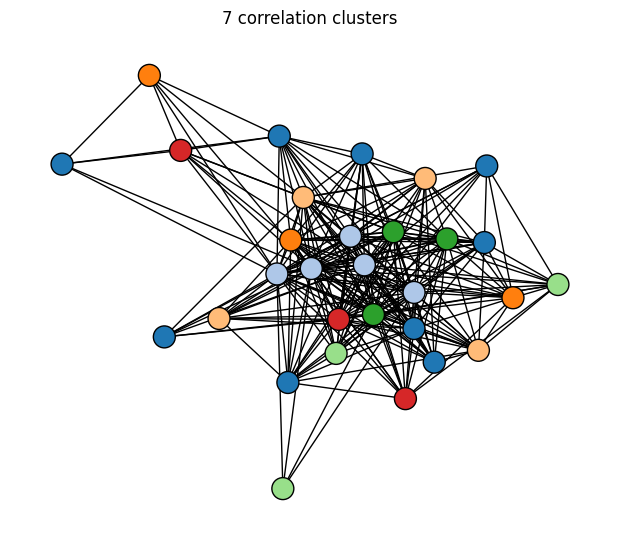

In [101]:
# 最終的な分割の可視化
color = {}
for ci, c in enumerate(clusters):
    for v in c:
        color[v] = ci

plt.figure(figsize=(6, 5))
nx.draw(G, pos, node_size=250, edgecolors="black", cmap=plt.cm.tab20,
        node_color=[color[v] for v in G.nodes()], vmin=0, vmax=19)
plt.title(f"{len(clusters)} correlation clusters")
plt.show()

## 結果

グラフ分割から得られた各クラスタから、学習期間のリターンが最大の銘柄を一つずつ選びます。
そしてテスト期間の日次リターンを平均して累積することで、資産の推移を計算します。
また、最終的な資産総額と、年率換算したシャープレシオを計算し、これらも表示しています。

selected 7 assets: ['ALK', 'ADI', 'ABBV', 'AAL', 'ADBE', 'AGN', 'ALGN']

PCE      final =  1289.77   sharpe = +1.692
baseline final =  1149.85   sharpe = +1.579


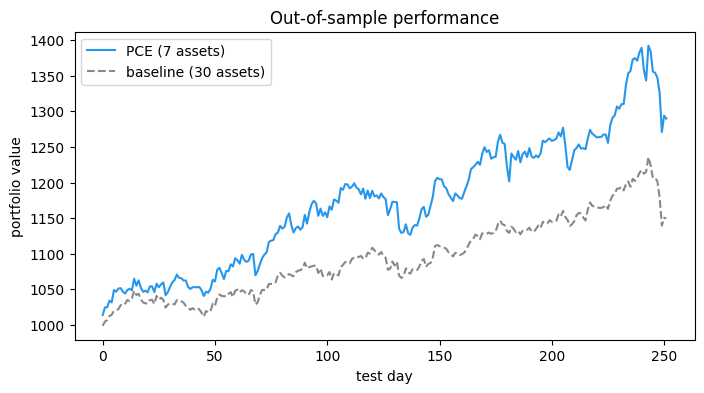

In [104]:
mu = train.mean().to_numpy()
reps = [max(c, key=lambda v: mu[v]) for c in clusters if len(c) > 0]

print(f"selected {len(reps)} assets: {[tickers[v] for v in reps]}")

equity = 1000 * (1 + test[[tickers[v] for v in reps]].mean(axis=1)).cumprod()
baseline = 1000 * (1 + test.mean(axis=1)).cumprod()

def sharpe(eq):
    r = eq.pct_change().dropna()
    return float(np.sqrt(252) * r.mean() / r.std()) if r.std() > 0 else 0.0

print(f"\nPCE      final = {equity.iloc[-1]:8.2f}   sharpe = {sharpe(equity):+.3f}")
print(f"baseline final = {baseline.iloc[-1]:8.2f}   sharpe = {sharpe(baseline):+.3f}")

plt.figure(figsize=(8, 4))
plt.plot(equity.values, label=f"PCE ({len(reps)} assets)", color="#2696EB")
plt.plot(baseline.values, label=f"baseline ({M} assets)", color="#888", ls="--")
plt.xlabel("test day"); plt.ylabel("portfolio value")
plt.legend(); plt.title("Out-of-sample performance")
plt.show()

ベースラインとして全ての銘柄を用いた場合のリターンも表示しています。
この場合、一貫して PCE により選び出した銘柄によるリターンが、ベースラインを上回っていることがわかります。
同様に、シャープレシオもベースラインを凌駕しています。

## まとめ

ここでは、PCE を応用したポートフォリオ最適化手法を考案した論文と、その実装を Qamomile で行う方法についてご紹介しました。
以下に、このページで紹介した重要な情報をまとめます。

* Qamomile には PCE を実装する機能が備わっており、`PCEConverter` でこれを呼び出すことができます。
* 各銘柄間の相関を用いてグラフを構築し、その MaxCut を行うことで、相関の強い銘柄どうしをクラスタリングします。
* このようにして選ばれた銘柄が、より良いリターン・シャープレシオとなることを示しました。